In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import awkward as ak
from pathlib import Path
import pickle
import os

import torch
import torchvision
print(torch.__version__)
print(torchvision.__version__)

import torch.nn as nn
import torch.nn.functional as F

2.10.0+rocm7.1
0.25.0+rocm7.1


In [30]:
# ============================================================================
# CONFIGURAZIONE
# ============================================================================

class JetAnalyzer:
    """
    Classe per analizzare dati jet da file Parquet
    """
    
    def __init__(self, filepath, max_events=None):
        
        self.filepath = Path(filepath)
        self.max_events = max_events
        self.data = None
        self.variables = {
            # Variabili dei jet (array per evento)
            'jet_pt': 'FullReco_JetAK4_PT',
            'jet_eta': 'FullReco_JetAK4_Eta',
            'jet_phi': 'FullReco_JetAK4_Phi',
            'jet_mass': 'FullReco_JetAK4_Mass',
            'jet_n': 'FullReco_JetAK4_N',
            
            # Quantità di controllo
            'jet_constituents': 'FullReco_JetAK4_Constituents',
            'jet_btag': 'FullReco_JetAK4_BTag',
            'jet_btag_phys': 'FullReco_JetAK4_BTagPhys',
            
            # MET (opzionale)
            'met_pt': 'FullReco_MET_pt',
            'met_phi': 'FullReco_MET_phi',
            
            # Variabili evento
            'event_number': 'eventNumber',
            'run_number': 'runNumber',
        }
        
        self._load_data()
    
    def _load_data(self):
        """Carica i dati dal file Parquet"""
        print(f"Caricamento file: {self.filepath}")
        print(f"File size: {self.filepath.stat().st_size / 1024**2:.2f} MB")
        
        try:
            # Carica il file Parquet
            self.data = pd.read_parquet(self.filepath)
            print(f"✅ Caricati {len(self.data)} eventi")
            
            # Limita eventi se richiesto
            if self.max_events and self.max_events < len(self.data):
                self.data = self.data.head(self.max_events)
                print(f"   Usati {len(self.data)} eventi")
            
            # Mostra colonne disponibili
            print(f"\nColonne disponibili:")
            for col in self.data.columns:  
                print(f"  - {col}")
            
        except Exception as e:
            print(f"❌ Errore nel caricamento: {e}")
            raise
    
    def extract_jet_data(self, event_idx):
        """
        Estrae i dati dei jet per un singolo evento
        """
        event = self.data.iloc[event_idx]
        
        jet_data = {}
        for key, col_name in self.variables.items():
            if col_name in event:
                value = event[col_name]
                
                # Gestisci diversi tipi di dati
                if value is None:
                    jet_data[key] = np.array([], dtype=np.float32)
                else:
                    jet_data[key] = value
        
        return jet_data
    
    def compute_jet_parameters(self, use_leading_jets=None, min_pt=30.0):
        
        all_jet_mass = []
        all_jet_pt = []
        all_jet_eta = []
        all_jet_cos_phi = []
        all_jet_sin_phi = []
        
        print(f"\nCaricamento parametri...")
        print(f"  Min PT: {min_pt} GeV")
        if use_leading_jets:
            print(f"  Usando: {use_leading_jets} leading jet")
        
        for idx in range(len(self.data)):
            jet_data = self.extract_jet_data(idx)
            
            jet_pt = jet_data['jet_pt']
            jet_eta = jet_data['jet_eta']
            jet_phi = jet_data['jet_phi']
            jet_mass = jet_data['jet_mass']
            
            # Applica taglio pt
            mask = jet_pt > min_pt
            jet_pt = jet_pt[mask]
            jet_eta = jet_eta[mask]
            jet_phi = jet_phi[mask]
            jet_mass = jet_mass[mask]
            
            # Seleziona leading jet
            if use_leading_jets:
                # Ordina per pt decrescente
                sorted_idx = np.argsort(jet_pt)[::-1]
                jet_mass = jet_mass[sorted_idx][:use_leading_jets]
                jet_pt = jet_pt[sorted_idx][:use_leading_jets]
                jet_eta = jet_eta[sorted_idx][:use_leading_jets]
                jet_phi = jet_phi[sorted_idx][:use_leading_jets]

            # Salvataggio parametri dei jet
            all_jet_mass.extend(jet_mass)
            all_jet_pt.extend(jet_pt)
            all_jet_eta.extend(jet_eta)
            all_jet_cos_phi.extend(np.cos(jet_phi))
            all_jet_sin_phi.extend(np.sin(jet_phi))
            
            if (idx + 1) % 1000 == 0:
                print(f"  Processati {idx + 1}/{len(self.data)} eventi")
        
        # Converti liste in array numpy
        all_jet_mass = np.array(all_jet_mass)
        all_jet_pt = np.array(all_jet_pt)
        all_jet_eta = np.array(all_jet_eta)
        all_jet_cos_phi = np.array(all_jet_cos_phi)
        all_jet_sin_phi = np.array(all_jet_sin_phi)
        
        return (all_jet_mass, all_jet_pt, all_jet_eta, all_jet_cos_phi, all_jet_sin_phi)

In [31]:
# Configurazione
DATA_FILE = "data/ZJetsToQQ_13TeV-madgraphMLM-pythia8-NEVENT10000-RS54000001.parquet"
OUTPUT_DIR = "model"

In [32]:
# Inizializza analizzatore e estrazione parametri + costituenti
analyzer = JetAnalyzer(DATA_FILE, max_events=None)  # None per tutti gli eventi

# Chiamata alla nuova funzione
(mass, jet_pt, jet_eta, jet_cos_phi, jet_sin_phi) = analyzer.compute_jet_parameters(
    use_leading_jets=2, min_pt=30
)

Caricamento file: data/ZJetsToQQ_13TeV-madgraphMLM-pythia8-NEVENT10000-RS54000001.parquet
File size: 1449.62 MB
✅ Caricati 9972 eventi

Colonne disponibili:
  - FullReco_PFCand_PT
  - FullReco_PFCand_Eta
  - FullReco_PFCand_Phi
  - FullReco_PFCand_PID
  - FullReco_PFCand_Charge
  - FullReco_PFCand_Mass
  - FullReco_PFCand_D0
  - FullReco_PFCand_DZ
  - FullReco_PFCand_ErrorD0
  - FullReco_PFCand_ErrorDZ
  - FullReco_PFCand_fUniqueID
  - FullReco_PFCand_PuppiW
  - FullReco_PUPPIPart_PT
  - FullReco_PUPPIPart_Eta
  - FullReco_PUPPIPart_Phi
  - FullReco_PUPPIPart_Charge
  - FullReco_PUPPIPart_Mass
  - FullReco_PUPPIPart_PID
  - FullReco_PUPPIPart_D0
  - FullReco_PUPPIPart_DZ
  - FullReco_PUPPIPart_ErrorD0
  - FullReco_PUPPIPart_ErrorDZ
  - FullReco_PUPPIPart_fUniqueID
  - FullReco_PUPPIPart_PuppiW
  - FullReco_Electron_PT
  - FullReco_Electron_Eta
  - FullReco_Electron_Phi
  - FullReco_Electron_EhadOverEem
  - FullReco_Electron_IsolationVarRhoCorr
  - FullReco_MuonTight_PT
  - FullReco_Muo

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ============================================================================
# NORMALIZZAZIONE DATI
# ============================================================================

print(f"\n{'='*60}")
print("NORMALIZZAZIONE DATI")
print(f"{'='*60}")

# Combina tutte le features in una singola matrice
features = np.column_stack([
    mass,
    jet_pt,
    jet_eta,
    jet_cos_phi,
    jet_sin_phi
])

print(f"Forma dati: {features.shape}")
print(f"Features: mass, jet_pt, jet_eta, jet_cos_phi, jet_sin_phi")

# Normalizza usando StandardScaler
scaler = StandardScaler()
features_normalized = scaler.fit_transform(features)

print(f"✅ Dati normalizzati")
print(f"  Mean: {scaler.mean_}")
print(f"  Std:  {scaler.scale_}")



NORMALIZZAZIONE DATI
Forma dati: (13252, 5)
Features: mass, jet_pt, jet_eta, jet_cos_phi, jet_sin_phi
✅ Dati normalizzati
  Mean: [ 6.63451702e+00  6.00048978e+01 -9.02467942e-02 -4.39215703e-03
  2.75021754e-03]
  Std:  [ 7.22137755 61.08427873  2.09493942  0.7061491   0.70804901]


In [34]:
# ============================================================================
# DATASET MASKED AUTOENCODER
# ============================================================================

class MaskedAutoencoderDataset(torch.utils.data.Dataset):
    """
    Dataset per masked autoencoder sulle 5 features aggregate
    """
    def __init__(self, features):
        """
        Args:
            features: array numpy di shape (n_samples, 5) - features aggregate
        """
        self.features = torch.FloatTensor(features)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx]  # [5] - mass, jet_pt, jet_eta, jet_cos_phi, jet_sin_phi

print(f"\n{'='*60}")
print("CREAZIONE DATASET MASKED AUTOENCODER")
print(f"{'='*60}")

# Split dei dati
X_train, X_temp = train_test_split(
    features_normalized,
    test_size=0.3,
    random_state=42
)

X_val, X_test = train_test_split(
    X_temp,
    test_size=0.5,
    random_state=42
)

print(f"✅ Split completato:")
print(f"  Train:      {X_train.shape[0]} campioni")
print(f"  Validation: {X_val.shape[0]} campioni")
print(f"  Test:       {X_test.shape[0]} campioni")

# Crea i dataset
train_dataset = MaskedAutoencoderDataset(X_train)
val_dataset = MaskedAutoencoderDataset(X_val)
test_dataset = MaskedAutoencoderDataset(X_test)

print(f"✅ Dataset masked autoencoder creati")
print(f"   Features shape: {X_train.shape}")


CREAZIONE DATASET MASKED AUTOENCODER
✅ Split completato:
  Train:      9276 campioni
  Validation: 1988 campioni
  Test:       1988 campioni
✅ Dataset masked autoencoder creati
   Features shape: (9276, 5)


In [35]:
BATCH_SIZE = 64
NUM_WORKERS = 2

In [36]:
# Crea i dataloader
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f"✅ Dataloader creati:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Train batches:      {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches:       {len(test_loader)}")

# Test: verifica che i dati vengono caricati correttamente
print(f"\n{'='*60}")
print("TEST DATALOADER")
print(f"{'='*60}")

for batch in train_loader:
    print(f"✅ Features batch shape: {batch.shape}")
    print(f"   (batch_size={batch.shape[0]}, n_features={batch.shape[1]})")
    break  # Solo il primo batch

✅ Dataloader creati:
  Batch size: 64
  Train batches:      145
  Validation batches: 32
  Test batches:       32

TEST DATALOADER
✅ Features batch shape: torch.Size([64, 5])
   (batch_size=64, n_features=5)


In [37]:
class AttentionBlock(nn.Module):
    """
    Standard attention block senza positional encoding
    """
    
    def __init__(self, embed_dim, hidden_dim, num_heads, dropout=0.1):
        super(AttentionBlock, self).__init__()
        
        self.layer_norm_1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.layer_norm_2 = nn.LayerNorm(embed_dim)
        
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout)
        )
          
    def forward(self, x):
        # x: [batch, seq_len, embed_dim]
        inp_x = self.layer_norm_1(x)
        attn_out, _ = self.attn(inp_x, inp_x, inp_x)
        x = x + attn_out
        x = self.layer_norm_2(x)
        x = x + self.mlp(x)
        return x


class FoundationEncoder(nn.Module):
    """
    Foundation Model: Transformer Encoder che produce embeddings contestuali
    Permutation invariant (senza positional encoding)
    """
    
    def __init__(self, 
                 input_dim=5,           # Numero di feature per jet
                 embed_dim=128,         # Dimensione embedding
                 hidden_dim=256,        # Dimensione hidden nei feed-forward
                 num_heads=8,           # Numero di teste di attenzione
                 num_layers=6,          # Numero di layer transformer
                 dropout=0.1):
        super(FoundationEncoder, self).__init__()
        
        self.input_dim = input_dim
        self.embed_dim = embed_dim
        
        # 1. Embedding delle feature
        # Ogni feature (pt, eta, sin_phi, cos_phi, mass) viene embedded separatamente
        self.feature_embed = nn.Linear(1, embed_dim)
        
        # 2. Transformer encoder (senza positional encoding!)
        self.encoder_layers = nn.ModuleList([
            AttentionBlock(embed_dim, hidden_dim, num_heads, dropout)
            for _ in range(num_layers)
        ])
        
        # 3. Layer norm finale
        self.encoder_norm = nn.LayerNorm(embed_dim)
        
        # 4. Pooling per ottenere rappresentazione globale (opzionale)
        self.pooling = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.Tanh()
        )
        
    def forward(self, x, return_embeddings=False):
        """
        Args:
            x: [batch_size, input_dim] - features aggregate
            return_embeddings: se True, ritorna embeddings per token
        
        Returns:
            if return_embeddings:
                token_embeddings: [batch, input_dim, embed_dim]
                global_embedding: [batch, embed_dim]
            else:
                global_embedding: [batch, embed_dim]
        """
        batch_size = x.shape[0]
        
        # Step 1: Embedding delle feature
        # [B, input_dim] -> [B, input_dim, embed_dim]
        x_embed = torch.stack([
            self.feature_embed(x[:, i:i+1]) 
            for i in range(self.input_dim)
        ], dim=1)
        
        # Step 2: Transformer encoder (senza positional encoding)
        x_encoded = x_embed
        for layer in self.encoder_layers:
            x_encoded = layer(x_encoded)
        
        x_encoded = self.encoder_norm(x_encoded)
        
        # Step 3: Pooling per ottenere rappresentazione globale
        # Mean pooling sui token (permutation invariant)
        global_embedding = x_encoded.mean(dim=1)  # [B, embed_dim]
        global_embedding = self.pooling(global_embedding)
        
        if return_embeddings:
            return x_encoded, global_embedding
        else:
            return global_embedding


class MaskedAutoencoderHead(nn.Module):
    """
    Task-specific head: Masked Autoencoder per pretraining
    """
    
    def __init__(self, embed_dim, input_dim, hidden_dim=128, dropout=0.1):
        super(MaskedAutoencoderHead, self).__init__()
        
        self.input_dim = input_dim
        self.embed_dim = embed_dim
        
        # Mask token (trainable)
        self.mask_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        
        # Decoder: da embedding a ricostruzione
        self.decoder = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )
        
    def forward(self, token_embeddings, mask_ratio=0.15):
        """
        Args:
            token_embeddings: [B, input_dim, embed_dim] embeddings dei token
            mask_ratio: float, ratio di token da mascherare
        
        Returns:
            recon: [B, input_dim] features ricostruite
            mask: [B, input_dim] posizioni mascherate
        """
        batch_size, seq_len, embed_dim = token_embeddings.shape
        
        # Genera maschera casuale
        mask = torch.rand(batch_size, seq_len, device=token_embeddings.device) < mask_ratio
        
        # Applica masking
        x_masked = token_embeddings.clone()
        x_masked[mask] = self.mask_token
        
        # Decodifica
        x_recon = self.decoder(x_masked).squeeze(-1)  # [B, input_dim]
        
        return x_recon, mask
    
class ClassificationHead(nn.Module):
    """
    Task-specific head: Classificazione
    """
    
    def __init__(self, embed_dim, num_classes, hidden_dim=64, dropout=0.1):
        super(ClassificationHead, self).__init__()
        
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
    
    def forward(self, global_embedding):
        return self.classifier(global_embedding)

class RegressionHead(nn.Module):
    """
    Task-specific head: Regressione (es. massa invariante)
    """
    
    def __init__(self, embed_dim, hidden_dim=64, dropout=0.1):
        super(RegressionHead, self).__init__()
        
        self.regressor = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, global_embedding):
        return self.regressor(global_embedding).squeeze(-1)


class JetFoundationModel(nn.Module):
    """
    Foundation Model per jet: encoder transformer + task-specific heads
    """
    
    def __init__(self,
                 input_dim=5,
                 embed_dim=128,
                 hidden_dim=256,
                 num_heads=8,
                 num_layers=6,
                 dropout=0.1,
                 num_classes=None,      # Per classificazione
                 use_autoencoder=False, # Per pretraining
                 use_regression=False): # Per regressione
        super(JetFoundationModel, self).__init__()
        
        # Foundation encoder (permutation invariant)
        self.encoder = FoundationEncoder(
            input_dim=input_dim,
            embed_dim=embed_dim,
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            num_layers=num_layers,
            dropout=dropout
        )
        
        self.use_autoencoder = use_autoencoder
        self.use_regression = use_regression
        
        # Task-specific heads
        if use_autoencoder:
            self.autoencoder_head = MaskedAutoencoderHead(
                embed_dim=embed_dim,
                input_dim=input_dim,
                hidden_dim=hidden_dim,
                dropout=dropout
            )
        
        if num_classes is not None:
            self.classification_head = ClassificationHead(
                embed_dim=embed_dim,
                num_classes=num_classes,
                hidden_dim=hidden_dim,
                dropout=dropout
            )
        
        if use_regression:
            self.regression_head = RegressionHead(
                embed_dim=embed_dim,
                hidden_dim=hidden_dim,
                dropout=dropout
            )
    
    def forward(self, x, task='autoencoder', mask_ratio=0.15):
        """
        Forward pass con task-specific behavior
        
        Args:
            x: [batch, input_dim] input features
            task: 'autoencoder', 'classification', 'regression', 'embeddings'
            mask_ratio: ratio per masking (solo per autoencoder)
        
        Returns:
            Dipende dal task
        """
        # Ottieni embeddings (token e global)
        token_embeddings, global_embedding = self.encoder(x, return_embeddings=True)
        
        if task == 'autoencoder':
            if not self.use_autoencoder:
                raise ValueError("Autoencoder head not initialized")
            recon, mask = self.autoencoder_head(token_embeddings, mask_ratio)
            return recon, x, mask  # x è il target
        
        elif task == 'classification':
            if not hasattr(self, 'classification_head'):
                raise ValueError("Classification head not initialized")
            return self.classification_head(global_embedding)
        
        elif task == 'regression':
            if not self.use_regression:
                raise ValueError("Regression head not initialized")
            return self.regression_head(global_embedding)
        
        elif task == 'embeddings':
            return token_embeddings, global_embedding
        
        else:
            raise ValueError(f"Unknown task: {task}")

In [38]:
# Istanzia il modello Masked Autoencoder

model_kwargs = {
    'input_dim': 5,           # 5 features aggregate: mass, jet_pt, jet_eta, jet_cos_phi, jet_sin_phi
    'embed_dim': 64,          # Dimensione dello spazio latente
    'hidden_dim': 256,        # Dimensione dello strato nascosto
    'num_heads': 8,
    'num_layers': 4,          # Non usato in questo modello semplice
    'dropout': 0.3,
    'use_autoencoder': True,  # Per pretraining
    'num_classes': None,       # Non ancora
    'use_regression': False
}

model = JetFoundationModel(**model_kwargs)

print("✅ Modello Masked Autoencoder istanziato")
print(f"   Input dim: {model_kwargs['input_dim']}")
print(f"   Embedding dim: {model_kwargs['embed_dim']}")

✅ Modello Masked Autoencoder istanziato
   Input dim: 5
   Embedding dim: 64


In [39]:
# Stampa la struttura del modello

print(model)

# Test forward pass con un batch dal dataloader
print("\n" + "="*60)
print("TEST FORWARD PASS")
print("="*60)

# Prendi un batch dal dataloader
batch = next(iter(train_loader))
batch_x = batch
print(f"✅ Input batch shape: {batch_x.shape}")

# Forward pass
recon, targets, masked_pos = model(batch_x, task='autoencoder', mask_ratio=0.15)
print(f"✅ Reconstruction shape: {recon.shape}")
print(f"✅ Targets shape: {targets.shape}")
print(f"✅ Masked positions shape: {masked_pos.shape}")

JetFoundationModel(
  (encoder): FoundationEncoder(
    (feature_embed): Linear(in_features=1, out_features=64, bias=True)
    (encoder_layers): ModuleList(
      (0-3): 4 x AttentionBlock(
        (layer_norm_1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (layer_norm_2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (mlp): Sequential(
          (0): Linear(in_features=64, out_features=256, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.3, inplace=False)
          (3): Linear(in_features=256, out_features=64, bias=True)
          (4): Dropout(p=0.3, inplace=False)
        )
      )
    )
    (encoder_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (pooling): Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): Tanh()
    )
  )
  (auto

In [40]:
class SimpleMaskedMSELoss(nn.Module):
    """
    Loss semplice con peso lineare crescente
    """
    
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()
        self.epoch = 0
        self.max_weight=10
        self.period=10
        self.start=5
    
    def forward(self, recon, targets, mask):
        # MSE su tutti i punti
        loss_all = self.mse(recon, targets)
        
        # MSE solo mascherati
        if mask.any():
            loss_masked = self.mse(recon[mask], targets[mask])
        else:
            loss_masked = torch.tensor(0.0, device=recon.device)
        
        # Peso che aumenta con l'epoca (da 0 a 2 nelle prime 20 epoche)
        weight = min(self.max_weight, (self.epoch - self.start) / self.period) if self.epoch > self.start else 0
        
        return loss_all + weight * loss_masked

In [41]:
# ============================================================================
# MASKED AUTOENCODER TRAINING LOOP
# ============================================================================

print("="*60)
print("MASKED AUTOENCODER TRAINING")
print("="*60)

# Configurazione training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n✅ Device: {device}")

model = model.to(device)

# Loss function
mae_criterion = SimpleMaskedMSELoss()#nn.MSELoss()

# Optimizer e scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Parametri training
num_epochs = 20
best_val_loss = float('inf')
checkpoint_path = Path(OUTPUT_DIR) / "best_foundation_model.pt"

# History per il plot
train_losses = []
val_losses = []

# Training loop
for epoch in range(num_epochs):
    # TRAIN
    model.train()
    train_loss = 0.0

    for batch in train_loader:
        batch_features = batch.to(device)

        # Forward pass
        recon, targets, masked_pos = model(batch_features)

        # Loss
        loss = mae_criterion(recon, targets, masked_pos)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Accumula loss
        train_loss += loss.item()

    # Media della loss di training
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # VALIDATION
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:
            batch_features = batch.to(device)

            # Forward pass
            recon, targets, masked_pos = model(batch_features)

            # Loss solo sulle posizioni mascherate
            loss = mae_criterion(recon, targets, masked_pos)

            val_loss += loss.item()

    # Media della loss di validation
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # Scheduler step
    scheduler.step(val_loss)

    # Salva il miglior modello
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), checkpoint_path)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.6f}")
        print(f"  Val Loss:   {val_loss:.6f}")

print(f"\n✅ Masked autoencoder training completato!")
print(f"   Miglior Val Loss: {best_val_loss:.6f}")
print(f"   Modello salvato: {checkpoint_path}")

MASKED AUTOENCODER TRAINING

✅ Device: cuda
Epoch 5/20
  Train Loss: 0.190115
  Val Loss:   0.177518
Epoch 10/20
  Train Loss: 0.202482
  Val Loss:   0.132332
Epoch 15/20
  Train Loss: 0.164921
  Val Loss:   0.166977
Epoch 20/20
  Train Loss: 0.179395
  Val Loss:   0.131005

✅ Masked autoencoder training completato!
   Miglior Val Loss: 0.131005
   Modello salvato: model/best_foundation_model.pt


PLOT MASKED AUTOENCODER TRAINING LOSSES


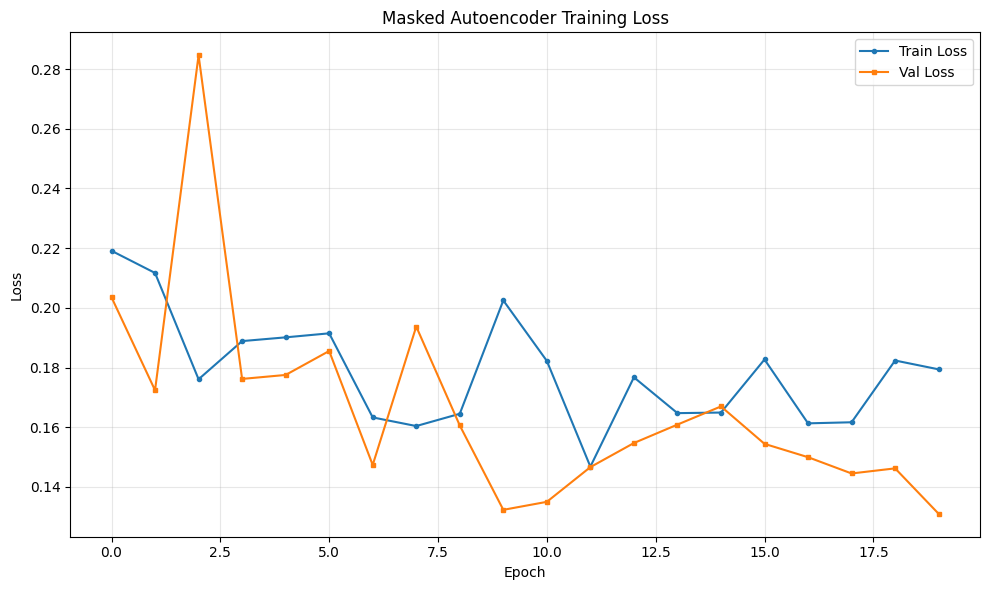

✅ Plot training losses salvato: model/mae_training_losses.png

EVALUATION SU TEST SET
✅ Test Results:
   Masked MSE Loss: 0.138168

VISUALIZZAZIONE MASKED AUTOENCODER


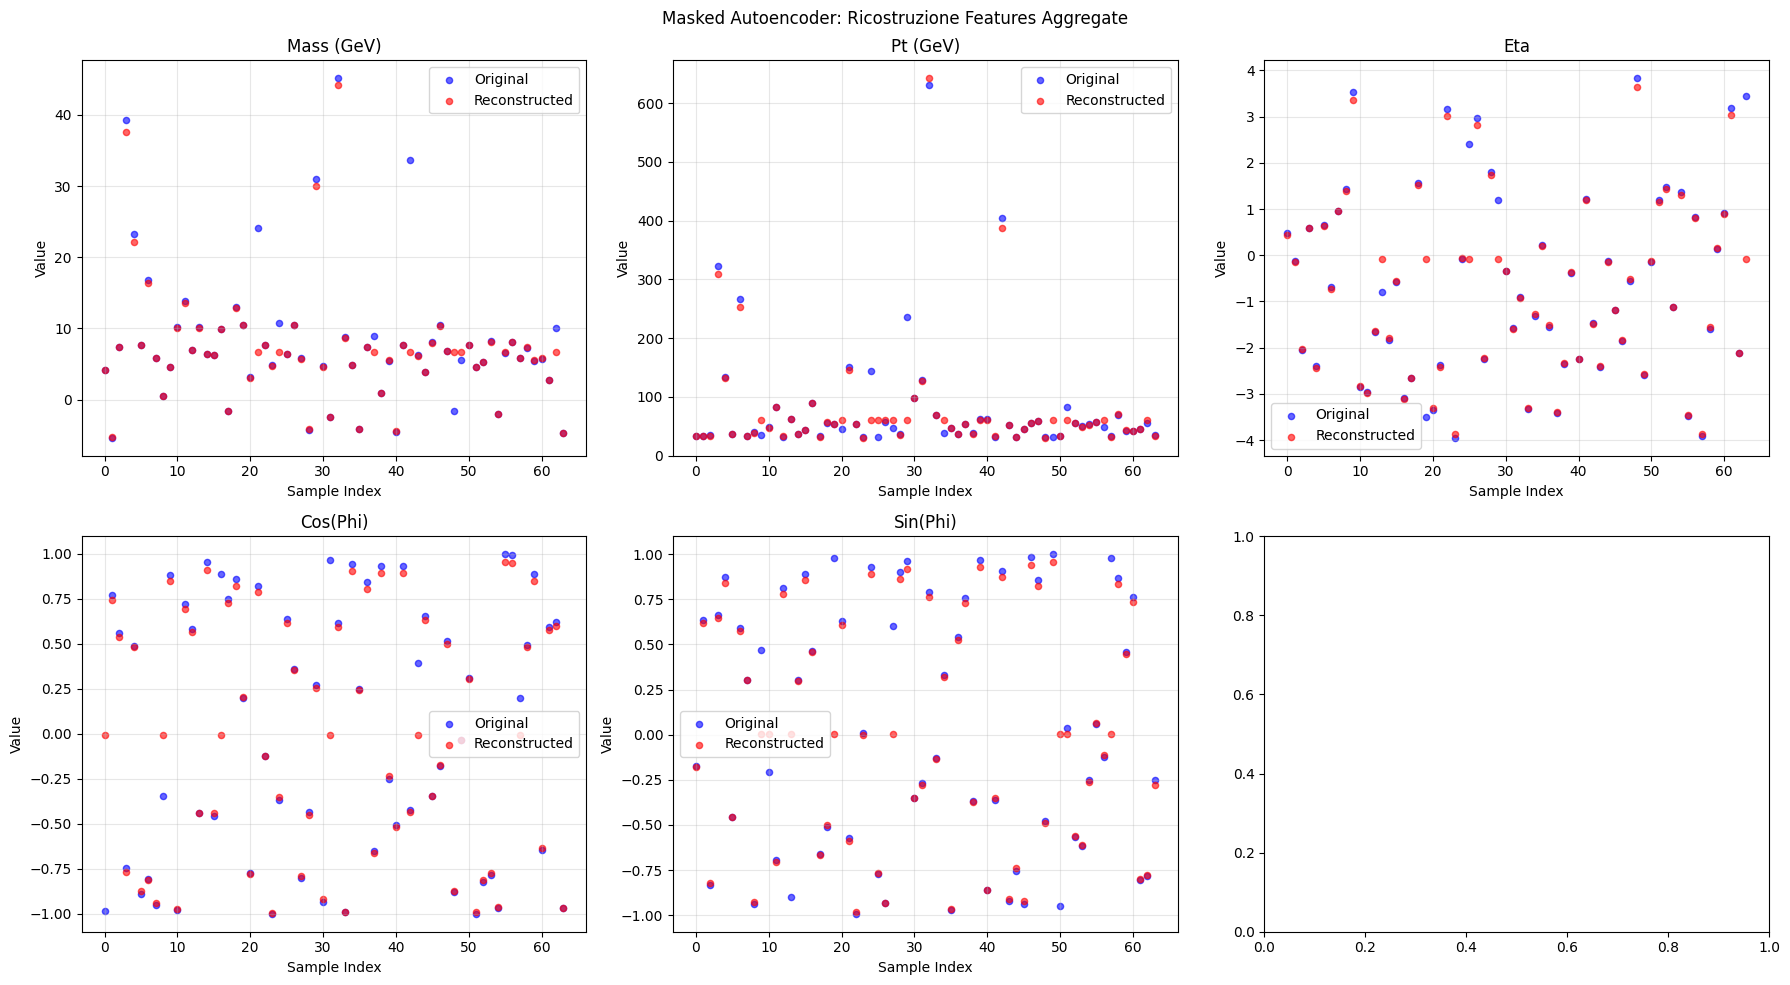

✅ Plot ricostruzioni MAE salvato: model/mae_reconstructions.png


In [42]:
# ============================================================================
# VISUALIZZAZIONE RISULTATI MASKED AUTOENCODER
# ============================================================================

print("="*60)
print("PLOT MASKED AUTOENCODER TRAINING LOSSES")
print("="*60)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(train_losses, label='Train Loss', marker='o', markersize=3)
ax.plot(val_losses, label='Val Loss', marker='s', markersize=3)
ax.set_title('Masked Autoencoder Training Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = Path(OUTPUT_DIR) / "mae_training_losses.png"
plt.savefig(plot_path, dpi=100, bbox_inches='tight')
plt.show()

print(f"✅ Plot training losses salvato: {plot_path}")

# ================================
# TEST SUL TEST SET
# ================================
print("\n" + "="*60)
print("EVALUATION SU TEST SET")
print("="*60)

model.load_state_dict(torch.load(checkpoint_path))
model.eval()

test_loss = 0.0

with torch.no_grad():
    for batch in test_loader:
        batch_features = batch.to(device)

        # Forward pass
        recon, targets, masked_pos = model(batch_features)

        # Loss solo sulle posizioni mascherate
        loss = mae_criterion(recon, targets, masked_pos)

        test_loss += loss.item()

test_loss /= len(test_loader)

print(f"✅ Test Results:")
print(f"   Masked MSE Loss: {test_loss:.6f}")

# ================================
# VISUALIZZAZIONE RICOSTRUZIONI
# ================================
print("\n" + "="*60)
print("VISUALIZZAZIONE MASKED AUTOENCODER")
print("="*60)

model.eval()
batch = next(iter(test_loader))
batch_features = batch.to(device)

with torch.no_grad():
    batch_recon, _, _ = model(batch_features)

# Denormalizza
batch_orig_denorm = scaler.inverse_transform(batch_features.cpu().numpy())
batch_recon_denorm = scaler.inverse_transform(batch_recon.cpu().numpy())

feature_names = ['Mass (GeV)', 'Pt (GeV)', 'Eta', 'Cos(Phi)', 'Sin(Phi)']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Masked Autoencoder: Ricostruzione Features Aggregate')

for i in range(5):
    row, col = i // 3, i % 3
    ax = axes[row, col]

    ax.scatter(range(min(100, len(batch_orig_denorm))),
               batch_orig_denorm[:100, i],
               alpha=0.6, label='Original', color='blue', s=20)
    ax.scatter(range(min(100, len(batch_recon_denorm))),
               batch_recon_denorm[:100, i],
               alpha=0.6, label='Reconstructed', color='red', s=20)

    ax.set_title(feature_names[i])
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
mae_plot_path = Path(OUTPUT_DIR) / "mae_reconstructions.png"
plt.savefig(mae_plot_path, dpi=100, bbox_inches='tight')
plt.show()

print(f"✅ Plot ricostruzioni MAE salvato: {mae_plot_path}")

In [43]:
# ================================
# SALVATAGGIO FINALE
# ================================

# Salva scaler e configurazione
model_info = {
    'scaler': scaler,
    'model_kwargs': model_kwargs,
    'best_val_loss': best_val_loss,
    'feature_names': ['mass', 'jet_pt', 'jet_eta', 'jet_cos_phi', 'jet_sin_phi']
}

torch.save(model_info, Path(OUTPUT_DIR) / "model_info.pt")

print(f"\n✅ Modello e configurazione salvati in: {Path(OUTPUT_DIR)}")
print(f"   - best_foundation_model.pt: pesi del modello")
print(f"   - model_info.pt: scaler, configurazione, feature names")
print(f"   - mae_training_losses.png: plot delle loss")
print(f"   - mae_reconstructions.png: visualizzazione ricostruzioni")

print(f"\n🎉 Masked autoencoder training completato con successo!")


✅ Modello e configurazione salvati in: model
   - best_foundation_model.pt: pesi del modello
   - model_info.pt: scaler, configurazione, feature names
   - mae_training_losses.png: plot delle loss
   - mae_reconstructions.png: visualizzazione ricostruzioni

🎉 Masked autoencoder training completato con successo!
